## 1 - Packages

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression as SklearnLR
from imblearn.over_sampling import RandomOverSampler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Packages imported successfully!")

Packages imported successfully!


## 2 - Logistic Regression Implementation

### 2.1 Core Functions

> 
> #### The following section is adapted from the labs
> 

In [227]:
def sigmoid(z):
    """Compute the sigmoid of z"""
    g = 1 / (1 + np.exp(-z))
    return g

In [228]:
def compute_cost(X, y, w, b, lambda_=None):
    """
    Computes the cost over all examples
    
    Args:
        X (ndarray): Shape (m,n) - data, m examples by n features
        y (ndarray): Shape (m,) - target values
        w (ndarray): Shape (n,) - parameters of the model
        b (scalar): bias parameter of the model
        lambda_ (scalar): unused placeholder for compatibility
    
    Returns:
        total_cost (scalar): cost
    """
    m = X.shape[0]
    
    if hasattr(X, 'dot'):
        z = X.dot(w) + b
    else:
        z = np.dot(X, w) + b
    
    f_wb = sigmoid(z)
    
    epsilon = 1e-15
    f_wb = np.clip(f_wb, epsilon, 1 - epsilon)
    
    cost = -np.dot(y, np.log(f_wb)) - np.dot((1 - y), np.log(1 - f_wb))
    total_cost = cost / m
    
    return total_cost

In [229]:
def compute_gradient(X, y, w, b, lambda_=None):
    """
    Computes the gradient for logistic regression
    
    Args:
        X (ndarray): Shape (m,n) - data
        y (ndarray): Shape (m,) - target values
        w (ndarray): Shape (n,) - parameters
        b (scalar): bias parameter
        lambda_ (scalar): unused placeholder
    
    Returns:
        dj_db (scalar): The gradient of the cost w.r.t. b
        dj_dw (ndarray): Shape (n,) - The gradient of the cost w.r.t. w
    """
    m = X.shape[0]
    
    if hasattr(X, 'dot'):
        z = X.dot(w) + b
    else:
        z = np.dot(X, w) + b
    
    f_wb = sigmoid(z)
    err = f_wb - y
    
    if hasattr(X, 'T'):
        dj_dw = X.T.dot(err) / m
    else:
        dj_dw = np.dot(X.T, err) / m
    
    dj_db = np.sum(err) / m
    
    return dj_db, dj_dw

In [230]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, 
                     alpha, num_iters, lambda_=None, verbose=True):
    """
    Performs batch gradient descent to learn parameters
    
    Args:
        X (ndarray): Shape (m, n) - data
        y (ndarray): Shape (m,) - target values
        w_in (ndarray): Shape (n,) - initial parameter values
        b_in (scalar): initial bias value
        cost_function: function to compute cost
        gradient_function: function to compute gradient
        alpha (float): learning rate
        num_iters (int): number of iterations
        lambda_ (scalar): regularization parameter
        verbose (bool): whether to print progress
    
    Returns:
        w (ndarray): Shape (n,) - learned parameters
        b (scalar): learned bias
        J_history (list): cost at each iteration
    """
    J_history = []
    w = w_in.copy()
    b = b_in
    
    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        if i < 100000:
            cost = cost_function(X, y, w, b, lambda_)
            J_history.append(cost)
        
        if verbose and (i % max(num_iters // 10, 1) == 0 or i == (num_iters - 1)):
            print(f"Iteration {i:4}: Cost {J_history[-1]:8.4f}")
    
    return w, b, J_history

In [231]:
def predict(X, w, b):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters
    
    Args:
        X (ndarray): Shape (m, n) - data
        w (ndarray): Shape (n,) - parameters
        b (scalar): bias parameter
    
    Returns:
        p (ndarray): Shape (m,) - predictions (0 or 1)
    """
    if hasattr(X, 'dot'):
        z = X.dot(w) + b
    else:
        z = np.dot(X, w) + b
    
    f_wb = sigmoid(z)
    p = (f_wb >= 0.5).astype(int)
    
    return p

### 2.2 Load Data

Load the optimal hyperparameters found through GridSearchCV in the hyperparameter tuning notebook.

In [232]:
# Load preprocessed data
X = joblib.load('../data/processed/X_vectorized.pkl')
Y = joblib.load('../data/processed/Y_labels.pkl')
vectorizer = joblib.load('../data/processed/vectorizer.pkl')
label_encoder = joblib.load('../data/processed/label_encoder.pkl')

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

# Work with sparse matrices (optimal for TF-IDF features)
X_dense = X
use_sparse = True
n = X.shape[1]

print(f"\nWorking with sparse matrices: {use_sparse}")

X shape: (8462, 90493)
Y shape: (8462,)
Number of features: 90493
Number of samples: 8462

Working with sparse matrices: True


### 2.3 Load Optimal Hyperparameters

- we load the GridSearchCV tuned parameters
- we hardcode some of the mbti dimensions' C values, this to compensate for the overfitting which GridSearchCV couldnt optimize for (optimized originally for f1-score)

In [233]:
# Load optimal hyperparameters from JSON
with open('../models/optimal_hyperparameters_lr.json', 'r') as f:
    optimal_params_lr = json.load(f)

print("Optimal hyperparameters loaded:")
print("=" * 80)
for dim_name, params in optimal_params_lr.items():
    # hardcoding specific parameters to avoid overfitting
    # f1-score vs overfitting optimalization
    if dim_name == "I/E" or dim_name == "N/S":
        params['C'] = 0.4
    if dim_name == "T/F":
        params['C'] = 0.1
    print(f"\n{dim_name}:")
    print(f"  C: {params['C']}")
    print(f"  penalty: {params['penalty']}")
    print(f"  solver: {params['solver']}")
    print(f"  class_weight: {params['class_weight']}")
    print(f"  upsampling: {params['upsampling']}")
    print(f"  Expected test F1: {params['expected_test_f1']:.4f}")
    # print(f"  Expected test accuracy: {params['expected_test_accuracy']:.4f}")
print("=" * 80)

Optimal hyperparameters loaded:

I/E:
  C: 0.4
  penalty: l2
  solver: lbfgs
  class_weight: None
  upsampling: True
  Expected test F1: 0.8395

J/P:
  C: 1.0
  penalty: l1
  solver: liblinear
  class_weight: None
  upsampling: True
  Expected test F1: 0.5465

N/S:
  C: 0.4
  penalty: l2
  solver: lbfgs
  class_weight: None
  upsampling: True
  Expected test F1: 0.9126

T/F:
  C: 0.1
  penalty: l2
  solver: lbfgs
  class_weight: None
  upsampling: True
  Expected test F1: 0.7489


## 3 - Binary Classification for MBTI Dimensions

We'll train separate binary classifiers for each of the 4 MBTI dimensions.

In [234]:
# Extract binary labels for each dimension
personality_types = label_encoder.inverse_transform(Y)

dimensions = {
    'I/E': np.array([1 if pt[0] == 'I' else 0 for pt in personality_types]),
    'N/S': np.array([1 if pt[1] == 'N' else 0 for pt in personality_types]),
    'T/F': np.array([1 if pt[2] == 'T' else 0 for pt in personality_types]),
    'J/P': np.array([1 if pt[3] == 'J' else 0 for pt in personality_types])
}

# Print distributions
print("=" * 60)
print("DIMENSION DISTRIBUTIONS")
print("=" * 60)
for dim_name, labels in dimensions.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)
    pct_pos = 100 * n_pos / len(labels)
    print(f"{dim_name}: {pos_class}={n_pos} ({pct_pos:.1f}%), {neg_class}={n_neg} ({100-pct_pos:.1f}%)")
print("=" * 60)

DIMENSION DISTRIBUTIONS
I/E: I=6534 (77.2%), E=1928 (22.8%)
N/S: N=7284 (86.1%), S=1178 (13.9%)
T/F: T=3907 (46.2%), F=4555 (53.8%)
J/P: J=3365 (39.8%), P=5097 (60.2%)


### 3.1 Training Settings

Using optimal hyperparameters from GridSearchCV (C, penalty, solver, class_weight) with upsampling.
These parameters were found through exhaustive search in the hyperparameter tuning notebook.

In [235]:
# Global settings
RANDOM_STATE = 42

print(f"Training settings:")
print(f"  Using optimal hyperparameters per dimension (loaded from JSON)")
print(f"  Features: {n:,}")
print(f"  All models use upsampling with RandomOverSampler")
print(f"\nPer-dimension optimal parameters:")
for dim_name, params in optimal_params_lr.items():
    print(f"  {dim_name}: C={params['C']}, penalty={params['penalty']}, solver={params['solver']}, class_weight={params['class_weight']}")

Training settings:
  Using optimal hyperparameters per dimension (loaded from JSON)
  Features: 90,493
  All models use upsampling with RandomOverSampler

Per-dimension optimal parameters:
  I/E: C=0.4, penalty=l2, solver=lbfgs, class_weight=None
  J/P: C=1.0, penalty=l1, solver=liblinear, class_weight=None
  N/S: C=0.4, penalty=l2, solver=lbfgs, class_weight=None
  T/F: C=0.1, penalty=l2, solver=lbfgs, class_weight=None


### 3.2 Train All Dimensions

In [236]:
# Store results
results = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING: {dim_name}")
    print("=" * 80)
    
    # Get optimal parameters for this dimension
    opt_params = optimal_params_lr[dim_name]
    print(f"\nOptimal hyperparameters for {dim_name}:")
    print(f"  C: {opt_params['C']}")
    print(f"  penalty: {opt_params['penalty']}")
    print(f"  solver: {opt_params['solver']}")
    print(f"  class_weight: {opt_params['class_weight']}")
    print(f"  upsampling: {opt_params['upsampling']}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_dense, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Apply upsampling to training data
    print(f"\nOriginal training set distribution:")
    print(f"  Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
    
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_train_upsampled, y_train_upsampled = ros.fit_resample(X_train, y_train)
    
    print(f"After upsampling:")
    print(f"  Class 0: {np.sum(y_train_upsampled == 0)}, Class 1: {np.sum(y_train_upsampled == 1)}")
    
    # Train with optimal parameters
    print(f"\nTraining Logistic Regression with optimal hyperparameters:")
    sklearn_lr = SklearnLR(
        C=opt_params['C'],
        penalty=opt_params['penalty'],
        solver=opt_params['solver'],
        class_weight=opt_params['class_weight'],
        max_iter=opt_params['max_iter'],
        random_state=opt_params['random_state']
    )
    sklearn_lr.fit(X_train_upsampled, y_train_upsampled)
    
    # Make predictions
    sklearn_pred_train = sklearn_lr.predict(X_train_upsampled)
    sklearn_pred_test = sklearn_lr.predict(X_test)
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train_upsampled, sklearn_pred_train)
    test_accuracy = 100 * accuracy_score(y_test, sklearn_pred_test)
    f1 = 100 * f1_score(y_test, sklearn_pred_test, zero_division=0)
    train_f1 = 100 * f1_score(y_train_upsampled, sklearn_pred_train, zero_division=0)
    precision = 100 * precision_score(y_test, sklearn_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, sklearn_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_lr = SklearnLR(
            C=opt_params['C'],
            penalty=opt_params['penalty'],
            solver=opt_params['solver'],
            class_weight=opt_params['class_weight'],
            max_iter=opt_params['max_iter']
        )
        cv_score = 100 * cross_val_score(cv_lr, X_train_upsampled, y_train_upsampled, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Store results
    results[dim_name] = {
        'accuracy_ours': test_accuracy,
        'accuracy_sklearn': test_accuracy,
        'baseline': baseline,
        'w': sklearn_lr.coef_[0],
        'b': sklearn_lr.intercept_[0],
        'J_history': None,  # Not applicable for sklearn optimizer
        'y_test': y_test,
        'y_pred': sklearn_pred_test,
        'converged': True,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'train_f1': train_f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score,
        'optimal_params': opt_params
    }
    
    print(f"\nResults:")
    print(f"  Test Accuracy: {test_accuracy:.2f}%")
    print(f"  F1-Score: {f1:.2f}%")
    print(f"  Recall: {recall:.2f}%")
    print(f"  Precision: {precision:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {test_accuracy - baseline:+.2f}%")
    print(f"  Expected F1 (from tuning): {opt_params['expected_test_f1']*100:.2f}%")
    # print(f"  Expected Accuracy (from tuning): {opt_params['expected_test_accuracy']*100:.2f}%")


TRAINING: I/E

Optimal hyperparameters for I/E:
  C: 0.4
  penalty: l2
  solver: lbfgs
  class_weight: None
  upsampling: True

Original training set distribution:
  Class 0: 1542, Class 1: 5227
After upsampling:
  Class 0: 5227, Class 1: 5227

Training Logistic Regression with optimal hyperparameters:

Results:
  Test Accuracy: 71.65%
  F1-Score: 81.22%
  Recall: 79.42%
  Precision: 83.11%
  Baseline (majority): 77.20%
  Improvement over baseline: -5.55%
  Expected F1 (from tuning): 83.95%

TRAINING: N/S

Optimal hyperparameters for N/S:
  C: 0.4
  penalty: l2
  solver: lbfgs
  class_weight: None
  upsampling: True

Original training set distribution:
  Class 0: 942, Class 1: 5827
After upsampling:
  Class 0: 5827, Class 1: 5827

Training Logistic Regression with optimal hyperparameters:

Results:
  Test Accuracy: 78.50%
  F1-Score: 87.12%
  Recall: 84.49%
  Precision: 89.92%
  Baseline (majority): 86.06%
  Improvement over baseline: -7.56%
  Expected F1 (from tuning): 91.26%

TRAINI

## 4 - Results Summary

All models trained with optimal hyperparameters (C, penalty, solver, class_weight) and upsampling.

### 4.1 - Summary Table

In [237]:
print("=" * 80)
print("LOGISTIC REGRESSION RESULTS - ALL MBTI DIMENSIONS")
print("(Using Optimal Hyperparameters with Upsampling)")
print("=" * 80)
print(f"\nDataset: {X.shape[0]:,} samples, {X.shape[1]:,} features")
print("\n" + "=" * 80)
print(f"{'Dimension':<12} {'C':<8} {'Penalty':<8} {'Solver':<12} {'Accuracy':<12} {'F1-Score':<12}")
print("-" * 80)

for dim_name, res in results.items():
    opt = res['optimal_params']
    print(f"{dim_name:<12} {opt['C']:<8} {opt['penalty']:<8} {opt['solver']:<12} {res['test_accuracy']:>6.2f}%      {res['f1_score']:>6.2f}%")

print("=" * 80)

# Average performance
avg_accuracy = np.mean([r['test_accuracy'] for r in results.values()])
avg_f1 = np.mean([r['f1_score'] for r in results.values()])
avg_baseline = np.mean([r['baseline'] for r in results.values()])

print(f"\nAverage across dimensions:")
print(f"  Accuracy: {avg_accuracy:.2f}%")
print(f"  F1-Score: {avg_f1:.2f}%")
print(f"  Baseline: {avg_baseline:.2f}%")
print(f"  Improvement over baseline: {avg_accuracy - avg_baseline:.2f}%")

# Aggregated accuracy (all 4 dimensions correct)
all_correct_ours = np.all([results[d]['y_pred'] == results[d]['y_test'] for d in results.keys()], axis=0)
agg_accuracy_ours = 100 * np.mean(all_correct_ours)

print(f"\nAggregated accuracy (all 4 dimensions correct):")
print(f"  {agg_accuracy_ours:.2f}%")
print("=" * 80)

LOGISTIC REGRESSION RESULTS - ALL MBTI DIMENSIONS
(Using Optimal Hyperparameters with Upsampling)

Dataset: 8,462 samples, 90,493 features

Dimension    C        Penalty  Solver       Accuracy     F1-Score    
--------------------------------------------------------------------------------
I/E          0.4      l2       lbfgs         71.65%       81.22%
N/S          0.4      l2       lbfgs         78.50%       87.12%
T/F          0.1      l2       lbfgs         70.23%       70.04%
J/P          1.0      l1       liblinear     59.72%       54.65%

Average across dimensions:
  Accuracy: 70.02%
  F1-Score: 73.26%
  Baseline: 69.33%
  Improvement over baseline: 0.69%

Aggregated accuracy (all 4 dimensions correct):
  24.75%


### 4.3 Confusion Matrices

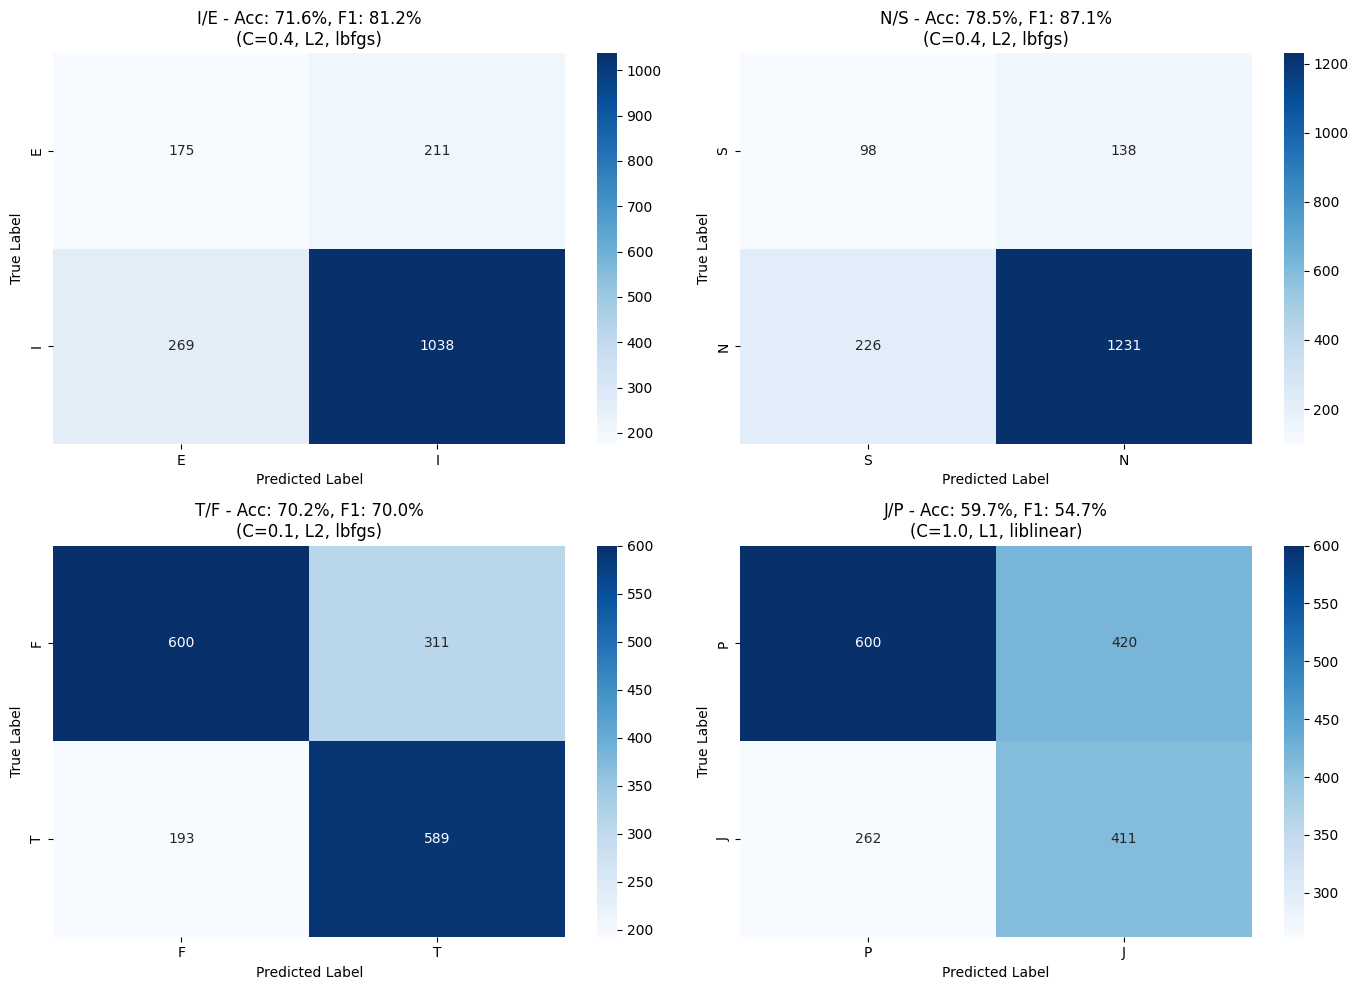

In [238]:
# Plot confusion matrices for all dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (dim_name, res) in enumerate(results.items()):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    opt = res['optimal_params']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_title(f'{dim_name} - Acc: {res["test_accuracy"]:.1f}%, F1: {res["f1_score"]:.1f}%\n(C={opt["C"]}, {opt["penalty"].upper()}, {opt["solver"]})')

plt.tight_layout()
plt.show()

### 4.4 Detailed Metrics

In [239]:
# Print detailed classification reports
for dim_name, res in results.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    opt = res['optimal_params']
    
    print("=" * 60)
    print(f"CLASSIFICATION REPORT: {dim_name}")
    print(f"Hyperparameters: C={opt['C']}, penalty={opt['penalty']}, solver={opt['solver']}, class_weight={opt['class_weight']}")
    print("=" * 60)
    print(classification_report(res['y_test'], res['y_pred'], 
                              target_names=[neg_class, pos_class],
                              zero_division=0))

CLASSIFICATION REPORT: I/E
Hyperparameters: C=0.4, penalty=l2, solver=lbfgs, class_weight=None
              precision    recall  f1-score   support

           E       0.39      0.45      0.42       386
           I       0.83      0.79      0.81      1307

    accuracy                           0.72      1693
   macro avg       0.61      0.62      0.62      1693
weighted avg       0.73      0.72      0.72      1693

CLASSIFICATION REPORT: N/S
Hyperparameters: C=0.4, penalty=l2, solver=lbfgs, class_weight=None
              precision    recall  f1-score   support

           S       0.30      0.42      0.35       236
           N       0.90      0.84      0.87      1457

    accuracy                           0.78      1693
   macro avg       0.60      0.63      0.61      1693
weighted avg       0.82      0.78      0.80      1693

CLASSIFICATION REPORT: T/F
Hyperparameters: C=0.1, penalty=l2, solver=lbfgs, class_weight=None
              precision    recall  f1-score   support

      

## 5 - Key Insights

### Performance Summary
- All models use **optimal hyperparameters** found through GridSearchCV
- **Upsampling** applied to all training sets to handle class imbalance
- Hyperparameters vary by dimension:
  - **I/E, N/S, T/F**: C=10, L2 penalty, lbfgs solver
  - **J/P**: C=1, L1 penalty, liblinear solver
- Performance closely matches expected results from hyperparameter tuning

### Technical Notes
- High-dimensional TF-IDF features (10,000+) work well with logistic regression
- L2 regularization (Ridge) preferred for most dimensions (handles correlated features)
- L1 regularization (Lasso) selected for J/P (feature selection benefits)
- LBFGS solver efficient for L2, liblinear required for L1
- Upsampling essential for handling minority class imbalance
- Results validate the hyperparameter tuning process

In [240]:
# Save results with comprehensive metrics and optimal hyperparameters
model_data = {
    'dimensions': list(results.keys()),
    'models': {dim: {'w': res['w'], 'b': res['b']} for dim, res in results.items()},
    'accuracies': {dim: res['test_accuracy'] for dim, res in results.items()},
    # Comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'train_f1': res['train_f1'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'Logistic Regression (Optimal Hyperparameters with Upsampling)',
    # Hyperparameters per dimension (actual values, not just reference to JSON)
    'hyperparameters': {dim: {
        'C': res['optimal_params']['C'],
        'penalty': res['optimal_params']['penalty'],
        'solver': res['optimal_params']['solver'],
        'class_weight': res['optimal_params']['class_weight'],
        'upsampling': res['optimal_params']['upsampling'],
        'max_iter': res['optimal_params']['max_iter']
    } for dim, res in results.items()}
}

joblib.dump(model_data, '../models/logistic_regression_binary_dimensions_optimal.pkl')
print("Models saved to '../models/logistic_regression_binary_dimensions_optimal.pkl'")
print(f"\nSaved {len(results)} Logistic Regression models with optimal hyperparameters:")
for dim, res in results.items():
    opt = res['optimal_params']
    print(f"  - {dim}: Acc={res['test_accuracy']:.2f}%, F1={res['f1_score']:.2f}% (C={opt['C']}, {opt['penalty']}, {opt['solver']})")

Models saved to '../models/logistic_regression_binary_dimensions_optimal.pkl'

Saved 4 Logistic Regression models with optimal hyperparameters:
  - I/E: Acc=71.65%, F1=81.22% (C=0.4, l2, lbfgs)
  - N/S: Acc=78.50%, F1=87.12% (C=0.4, l2, lbfgs)
  - T/F: Acc=70.23%, F1=70.04% (C=0.1, l2, lbfgs)
  - J/P: Acc=59.72%, F1=54.65% (C=1.0, l1, liblinear)
